# 05c — Baseline: Random Forest
**RouteRight AI — Stage 6 (Model Development)** | Owner: *(write team member name / ID here)*

This notebook runs **one** baseline model — **Random Forest** — in two variants (unweighted and class-weighted) and records its results.
Everything that must be identical across the four models (data, `TimeSeriesSplit` folds, threshold, metric definitions, seed, weighting logic) lives in **`baseline_common.py`**, so the models are compared on exactly the same footing. The four results are merged in `05e_Baseline_Comparison.ipynb`.

* **Validation:** 5-fold `TimeSeriesSplit` on `train.csv` only — each fold trains on earlier rows and validates on the next block.
* **Metrics:** PR-AUC and F1 are primary (test set is more imbalanced than train: 37% vs 47% positive); accuracy, precision, recall, ROC-AUC also reported.
* **Test set:** never loaded. Kept sealed until `07_Model_Evaluation.ipynb`.
* **Baseline = library defaults.** Tuning is Stage 7.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

import baseline_common as bc

MODEL_NAME = "Random Forest"
print("Project root:", bc.ROOT)

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor


## 2. Load training data and sanity checks
Only `train.csv` is loaded. `load_train()` asserts no missing values, all-numeric features, and **chronological row order** (the assumption `TimeSeriesSplit` depends on; `opened_month` is the only time signal in this file).

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## 3. Validation folds
Fold 1 trains on only ~3,500 rows (mostly Feb/March), so per-fold scores are shown, not only the mean.
**Caveat:** train contains 1,865 exact duplicate rows; a duplicate can sit on both sides of a fold boundary, making validation scores slightly optimistic (most visibly for trees). They are kept, not dropped, to preserve the documented class balance.

In [3]:
bc.fold_table(X, y)

,fold,n_train,n_val,train_pos_rate,val_pos_rate,val_months
0,1,3530,3530,0.5521,0.6110,[3]
1,2,7060,3530,0.5816,0.4530,"[3, 4]"
2,3,10590,3530,0.5387,0.4261,[4]
3,4,14120,3530,0.5106,0.3742,"[4, 5]"
4,5,17650,3530,0.4833,0.4110,[5]


## Why a Random Forest, and how it is set up
* **Role:** a **bagging ensemble** of decision trees, each grown on a bootstrap sample with random feature subsets. Averaging decorrelated trees cancels much of a single tree's overfitting, and it can capture interactions between features without manual engineering.
* **Settings:** defaults — 100 trees, no depth limit, `max_features="sqrt"`, `n_jobs=-1`.
* **Scaling:** not needed. The correlated ordinal features (impact/urgency/priority) are not a problem for trees.
* **Weighted variant:** `class_weight="balanced"`.
* **Expected:** each tree still overfits, but the forest should generalise far better than the single Decision Tree in `05b`.

In [4]:
bc.MODEL_FACTORIES[MODEL_NAME]("balanced")     # the weighted variant; unweighted is identical with class_weight=None

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

## 4. Cross-validated results

In [5]:
folds_df, oof_df = bc.run_cv(MODEL_NAME, X, y)
summary = bc.summarize(folds_df)
summary[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "fit_seconds"]]

cross-validated: Random Forest (unweighted)
cross-validated: Random Forest (weighted)


,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,fit_seconds
0,Random Forest,weighted,0.7374,0.0603,0.6813,0.6929,0.6743,0.7147,0.7751,0.9894,0.38
1,Random Forest,unweighted,0.7373,0.0560,0.6801,0.7122,0.6581,0.7055,0.7733,0.9894,0.33


Per-fold PR-AUC next to the **no-skill level** (a model with no skill scores the positive rate of that validation block, so compare each fold against its own line, not against other folds).

In [6]:
bc.per_fold_view(folds_df)

,n_train,no_skill_pr_auc,pr_auc_unweighted,pr_auc_weighted
fold,,,,
1,3530,0.611,0.831,0.840
2,7060,0.453,0.704,0.700
3,10590,0.426,0.688,0.693
4,14120,0.374,0.722,0.712
5,17650,0.411,0.741,0.742


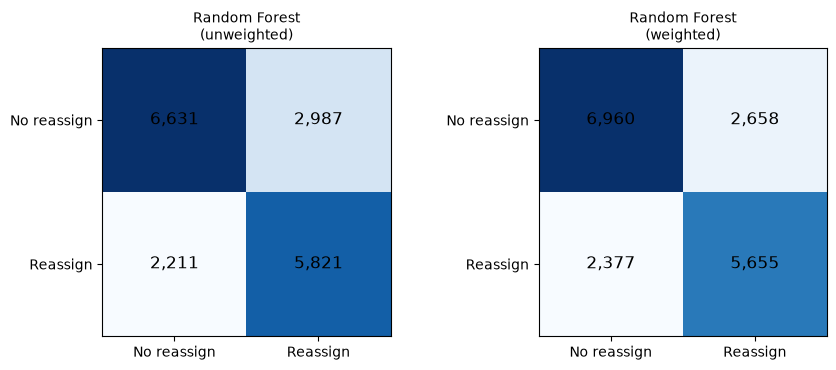

In [7]:
# Confusion matrices from pooled out-of-fold predictions (validation blocks of folds 1-5). Rows = actual, columns = predicted.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, variant in zip(axes, ["unweighted", "weighted"]):
    part = oof_df[oof_df.variant == variant]
    cm = confusion_matrix(part.y_true, part.y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No reassign", "Reassign"]); ax.set_yticklabels(["No reassign", "Reassign"])
    ax.set_title(f"{MODEL_NAME}\n({variant})", fontsize=10)
plt.tight_layout(); plt.savefig(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_confusion.png", dpi=130); plt.show()

## 5. Fit on the full training set and save
The model is refit on **all** of `train.csv` and saved to `models/baseline/`. Full-train accuracy is used in the comparison notebook to check against the training-accuracy ceiling. **No test data is used.**

In [8]:
full_df, fitted = bc.full_fit_and_save(MODEL_NAME, X, y)
bc.save_outputs(MODEL_NAME, folds_df, oof_df, full_df)
full_df

Saved results for Random Forest to C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval2


,model,variant,train_accuracy_full,train_f1_full
0,Random Forest,unweighted,0.9896,0.9889
1,Random Forest,weighted,0.9896,0.9889


## 6. Interpretation — feature importance

Full-train accuracy: 0.9896 | CV validation accuracy: 0.7055


,gini_importance
opened_hour,0.1364
opened_day_of_week,0.0946
opened_month,0.0502
assignment_group_20,0.0288
u_symptom_534,0.0204
location_204,0.0194
location_Other,0.0188
opened_by_17,0.0188
opened_by_Other,0.0173
assignment_group_70,0.0172


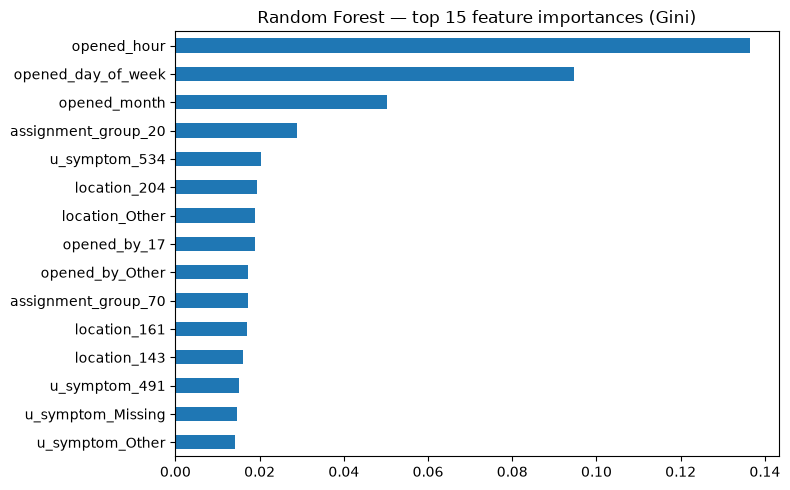

In [9]:
rf = fitted["unweighted"]
print("Full-train accuracy:", full_df.loc[full_df.variant == "unweighted", "train_accuracy_full"].iloc[0],
      "| CV validation accuracy:", summary.loc[summary.variant == "unweighted", "accuracy"].iloc[0])
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(15)
display(top.round(4).to_frame("gini_importance"))
top.iloc[::-1].plot.barh(figsize=(8, 5), title="Random Forest — top 15 feature importances (Gini)")
plt.tight_layout(); plt.savefig(bc.OUT_DIR / "baseline_random_forest_importance.png", dpi=130); plt.show()

## 7. Observations (numbers from the run above — re-check if you change anything)
1. **Best baseline on the primary metric:** PR-AUC ≈ 0.737 (unweighted) / 0.736 (weighted), F1 ≈ 0.68–0.69, recall ≈ 0.71.
2. **Still memorises the training data** (full-train accuracy ≈ 0.99, the same as the unconstrained tree), yet validates far better than the single Decision Tree (PR-AUC ≈ 0.74 vs ≈ 0.55). This is the variance-reduction effect of averaging many decorrelated trees.
3. **The lead over Gradient Boosting and Logistic Regression is small** (≈ 0.01–0.02 PR-AUC) relative to fold-to-fold std (≈ 0.05), so the baseline cannot declare a clear winner; that is decided after tuning.
4. **Trend across folds:** PR-AUC rises in later folds (0.69 → 0.72 → 0.74 in folds 3–5) and its gain over no-skill grows from ≈ 0.26 to ≈ 0.33–0.35. Logistic Regression's gain also rises (≈ 0.24 → 0.27–0.30), so this alone does not show that the forest benefits more from extra data; the forest simply keeps a slightly larger margin in every later fold.
5. **Importance caution:** `opened_hour` and `opened_day_of_week` rank at the top of Gini importance, but this measure is biased toward features with many split points; Stage 7 should confirm with **permutation importance** before drawing conclusions.
6. **Class weighting** changes little (PR-AUC 0.7373 vs 0.7363).
7. **Stage 7 plan:** tune `max_depth`, `min_samples_leaf`, `max_features`, `n_estimators` with `RandomizedSearchCV` + `TimeSeriesSplit`.